# TP2 — Estatística e Probabilidade Aplicada
### CloudDesk — Análise da base consolidada de tickets de suporte

Este notebook usa a **base consolidada de tickets** (resultado do TP1: merge de
`tickets_suporte.csv`, `planos_clientes.xlsx` e `chatbot_triagem.json`, com
tratamento de nulos, conversão de tipos e remoção de duplicatas) para responder
às 9 questões propostas.

## Setup e carregamento da base consolidada

Reaplico aqui, de forma resumida, os passos de limpeza feitos no TP1, para que o
notebook seja autocontido e reprodutível:

- `tempo_resposta_horas` veio como texto com vírgula decimal (`"1,54"`) → convertido para `float` com `str.replace(",", ".")` + `pd.to_numeric`.
- `data_abertura` convertida para `datetime`.
- Registros duplicados (reenvios de ticket, mesmo `ticket_id`) removidos com `drop_duplicates(subset="ticket_id", keep="first")` — mantém a primeira ocorrência, que corresponde ao ticket original.
- Merge **left** de `tickets_suporte` com `planos_clientes` por `cliente_id` (todo ticket tem um cliente com plano cadastrado, então o left join não perde linhas).
- Merge **left** de `tickets_suporte` com `chatbot_triagem` por `ticket_id` (só tickets do canal `chat` têm registro de triagem; os demais ficam `NaN` em `intencao_triagem`/`confianca_bot`, o que é esperado e não é um erro de dado).
- Valores nulos em `tempo_resposta_horas` e `satisfacao_cliente` (falhas reais de exportação) **não são imputados**: cada exercício usa `.dropna()` na variável específica que está analisando, para não distorcer a distribuição com valores inventados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ---- 1. Carregar os 3 arquivos brutos do TP1 ----
df_raw = pd.read_csv("tickets_suporte.csv")
planos = pd.read_excel("planos_clientes.xlsx")
with open("chatbot_triagem.json", encoding="utf-8") as f:
    triagem = pd.DataFrame(json.load(f))

# ---- 2. Limpeza ----
df_raw["tempo_resposta_horas"] = (
    df_raw["tempo_resposta_horas"].astype(str).str.replace(",", ".", regex=False)
)
df_raw["tempo_resposta_horas"] = pd.to_numeric(df_raw["tempo_resposta_horas"], errors="coerce")
df_raw["data_abertura"] = pd.to_datetime(df_raw["data_abertura"])

n_antes = len(df_raw)
df_raw = df_raw.drop_duplicates(subset="ticket_id", keep="first")
print(f"Duplicatas removidas: {n_antes - len(df_raw)} (de {n_antes} para {len(df_raw)} linhas)")

# ---- 3. Merge ----
df = df_raw.merge(planos, on="cliente_id", how="left")
df = df.merge(triagem, on="ticket_id", how="left")

print("\nShape da base consolidada:", df.shape)
print("\nDtypes:")
print(df.dtypes)

Duplicatas removidas: 80 (de 4080 para 4000 linhas)

Shape da base consolidada: (4000, 13)

Dtypes:
ticket_id                           str
cliente_id                          str
data_abertura            datetime64[us]
canal                               str
categoria                           str
prioridade                          str
tempo_resposta_horas            float64
tempo_resolucao_horas           float64
satisfacao_cliente              float64
valor_plano                       int64
segmento                            str
intencao_triagem                    str
confianca_bot                   float64
dtype: object


In [2]:
df.head()

,ticket_id,cliente_id,data_abertura,canal,categoria,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente,valor_plano,segmento,intencao_triagem,confianca_bot
0,TCK-00001,CLI-017,2026-01-05,chat,duvida_de_uso,media,1.540,6.834,4.000,99,enterprise,reclamacao,0.920
1,TCK-00002,CLI-140,2026-01-05,email,cobranca,media,2.050,6.664,5.000,199,starter,NaN,NaN
2,TCK-00003,CLI-118,2026-01-05,telefone,bug,baixa,2.040,6.185,4.000,199,starter,NaN,NaN
3,TCK-00004,CLI-079,2026-01-05,email,bug,critica,5.190,10.471,3.000,99,starter,NaN,NaN
4,TCK-00005,CLI-078,2026-01-05,chat,cobranca,baixa,0.630,3.049,4.000,199,starter,solicitacao,0.900


In [3]:
print("Valores nulos por coluna:")
df.isna().sum()

Valores nulos por coluna:


ticket_id                   0
cliente_id                  0
data_abertura               0
canal                       0
categoria                   0
prioridade                  0
tempo_resposta_horas      320
tempo_resolucao_horas       0
satisfacao_cliente        400
valor_plano                 0
segmento                    0
intencao_triagem         2603
confianca_bot            2603
dtype: int64

## Exercício 1 — Probabilidades a partir das frequências observadas

**Tarefa:** estimar P(alta), P(2º ticket na mesma semana) e P(alta OU chat) por frequência relativa.

In [4]:
# 1a) P(prioridade = "alta")
p_alta = (df["prioridade"] == "alta").mean()
print(f'P(prioridade = "alta") = {p_alta:.4f} ({p_alta*100:.1f}%)')
df["prioridade"].value_counts(normalize=True)

P(prioridade = "alta") = 0.2540 (25.4%)


prioridade
media     0.351
baixa     0.296
alta      0.254
critica   0.098
Name: proportion, dtype: float64

**P(alta) ≈ 0,254** — cerca de 1 em cada 4 tickets é aberto com prioridade alta.

In [5]:
# 1b) P(cliente abrir um 2º ticket na mesma semana)
# Definimos "semana" pela semana ISO da data_abertura. Agrupamos por (cliente, semana)
# e contamos quantos tickets aquele cliente abriu naquela semana. A probabilidade pedida
# é a fração dessas combinações (cliente, semana) em que o cliente abriu 2 ou mais tickets
# -- ou seja, entre as vezes que um cliente teve atividade numa semana, com que frequência
# ele chegou a abrir um segundo ticket na mesma semana.
df["semana"] = (
    df["data_abertura"].dt.isocalendar().year.astype(str)
    + "-W" + df["data_abertura"].dt.isocalendar().week.astype(str).str.zfill(2)
)
tickets_por_semana = df.groupby(["cliente_id", "semana"]).size().reset_index(name="n_tickets")

print("Distribuição do nº de tickets por (cliente, semana):")
print(tickets_por_semana["n_tickets"].value_counts().sort_index())

p_segundo_ticket = (tickets_por_semana["n_tickets"] >= 2).mean()
print(f'\nP(cliente abrir >= 2 tickets na mesma semana) = {p_segundo_ticket:.4f} ({p_segundo_ticket*100:.1f}%)')

Distribuição do nº de tickets por (cliente, semana):
n_tickets
1    1690
2     719
3     228
4      42
5       4
Name: count, dtype: int64

P(cliente abrir >= 2 tickets na mesma semana) = 0.3701 (37.0%)


**P(2º ticket na mesma semana) ≈ 0,370** — em cerca de 37% das semanas em que um
cliente teve algum ticket, ele abriu mais de um. É uma frequência alta o suficiente para
justificar, por exemplo, um alerta de "cliente recorrente" no suporte.

In [6]:
# 1c) P(alta OU chat), com correção de sobreposição
p_chat = (df["canal"] == "chat").mean()
p_alta_e_chat = ((df["prioridade"] == "alta") & (df["canal"] == "chat")).mean()
p_alta_ou_chat = p_alta + p_chat - p_alta_e_chat

print(f"P(alta)         = {p_alta:.4f}")
print(f"P(chat)         = {p_chat:.4f}")
print(f"P(alta E chat)  = {p_alta_e_chat:.4f}  <- sobreposição, contada duas vezes se não subtraída")
print(f"P(alta OU chat) = P(alta) + P(chat) - P(alta E chat) = {p_alta_ou_chat:.4f} ({p_alta_ou_chat*100:.1f}%)")

P(alta)         = 0.2540
P(chat)         = 0.3493
P(alta E chat)  = 0.0872  <- sobreposição, contada duas vezes se não subtraída
P(alta OU chat) = P(alta) + P(chat) - P(alta E chat) = 0.5160 (51.6%)


**P(alta OU chat) ≈ 0,516.** Os eventos "prioridade alta" e "canal chat" não são
mutuamente exclusivos — um ticket pode perfeitamente ser alta prioridade **e** ter sido
aberto pelo chat (≈8,7% dos tickets, `P(alta ∩ chat)`). Por isso a regra usada é a da
**soma com correção de sobreposição**: `P(A ∪ B) = P(A) + P(B) − P(A ∩ B)`. Se somássemos
P(alta) + P(chat) diretamente (≈0,603) estaríamos contando os tickets "alta e chat" duas
vezes, superestimando a probabilidade real.

## Exercício 2 — Variáveis contínuas vs. discretas

**Tarefa:** classificar `tempo_resposta_horas`, `satisfacao_cliente` e `categoria`, e
identificar a família de PDF/PMF adequada para uma variável de cada tipo.

In [7]:
print("Exemplos de valores observados em cada variável:\n")
print("tempo_resposta_horas (amostra):", df["tempo_resposta_horas"].dropna().sample(5, random_state=1).round(2).tolist())
print("satisfacao_cliente (valores únicos):", sorted(df["satisfacao_cliente"].dropna().unique()))
print("categoria (valores únicos):", df["categoria"].unique().tolist())

Exemplos de valores observados em cada variável:

tempo_resposta_horas (amostra): [3.52, 0.28, 5.14, 3.4, 6.75]
satisfacao_cliente (valores únicos): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
categoria (valores únicos): ['duvida_de_uso', 'cobranca', 'bug', 'elogio']


**Classificação:**

- **`tempo_resposta_horas` — variável CONTÍNUA.** É medida em horas e, na prática, pode
  assumir qualquer valor real dentro de um intervalo (1,54h; 2,05h; 0,63h...), não é
  contável em unidades discretas — entre dois tempos quaisquer sempre existe (em
  princípio) outro valor intermediário possível.

- **`satisfacao_cliente` — variável DISCRETA (categórica ordinal).** A base mostra que os
  únicos valores possíveis são `{1, 2, 3, 4, 5}` — uma escala Likert de nota inteira.
  É contável e finita: não existe "3,7" nessa variável, e os valores têm uma ordem natural
  (nota 5 > nota 4).

- **`categoria` — variável DISCRETA (categórica nominal).** Assume um número finito e
  fixo de rótulos (`bug`, `duvida_de_uso`, `cobranca`, `elogio`), sem ordem natural entre
  eles — não faz sentido dizer que "bug" é "maior" que "elogio". É contável por definição.

**PDF para a variável contínua (`tempo_resposta_horas`):**

Uma distribuição **Gama (Gamma)** — ou, alternativamente, **Log-normal** — é a família mais
adequada para descrever `tempo_resposta_horas`. Ambas são distribuições contínuas definidas
apenas para valores positivos (não existe tempo de resposta negativo) e com cauda longa à
direita, o que combina com o padrão observado: a maioria dos tickets é respondida rápido,
mas uma minoria demora muito mais, puxando a cauda da distribuição para a direita (assimetria
positiva). Uma Normal seria inadequada aqui porque ela permitiria valores negativos e é
simétrica, o que não reflete a forma real dos dados (isso é verificado numericamente no
Exercício 9). A família Gama, especificamente, é a escolha mais natural porque tempos de
resposta costumam poder ser vistos como a soma/acúmulo de pequenas esperas (fila, triagem,
atendimento) — um comportamento que a distribuição Gama modela bem.

**PMF para a variável discreta (`satisfacao_cliente`):**

Como `satisfacao_cliente` tem um conjunto pequeno e fixo de resultados possíveis (1 a 5,
cada um com uma probabilidade própria, não igualmente prováveis, como visto na Questão 8),
o formato mais direto é uma **distribuição Categórica (multinomial de uma tentativa)**, em que
a PMF simplesmente atribui uma probabilidade a cada uma das 5 notas: `P(X = k) = p_k` para
`k ∈ {1,2,3,4,5}`, estimadas pela frequência relativa observada de cada nota. Uma alternativa
mencionada na literatura para notas ordinais é a **Binomial** (tratando a nota como
"sucessos" em `n=4` tentativas, escala 1 a 5), mas ela impõe uma forma específica
(quase-simétrica em torno do centro) que não é obrigatória aqui — a Categórica é mais
flexível e não assume nenhuma forma particular além do que os dados mostram.

## Exercício 3 — CDF empírica de `tempo_resposta_horas`

**Tarefa:** estimar a distribuição empírica e usar a CDF para calcular a proporção de
tickets com tempo de resposta acima de 10h.

N de tickets com tempo_resposta_horas válido: 3680 (de 4000 linhas totais)


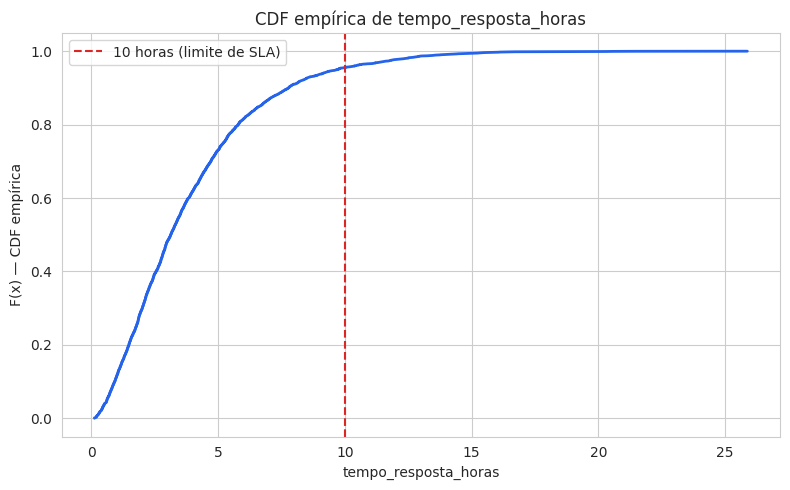

In [8]:
tr = df["tempo_resposta_horas"].dropna().values
print(f"N de tickets com tempo_resposta_horas válido: {len(tr)} (de {len(df)} linhas totais)")

tr_sorted = np.sort(tr)
cdf_empirica = np.arange(1, len(tr_sorted) + 1) / len(tr_sorted)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tr_sorted, cdf_empirica, color="#2563eb", lw=2)
ax.axvline(10, color="#dc2626", linestyle="--", label="10 horas (limite de SLA)")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("F(x) — CDF empírica")
ax.set_title("CDF empírica de tempo_resposta_horas")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Proporção de tickets com tempo de resposta ACIMA de 10h, via CDF empírica:
# P(X > 10) = 1 - F(10), onde F(10) é lida diretamente na CDF empírica.
proporcao_acima_10 = (tr > 10).mean()
F_10 = (tr <= 10).mean()

print(f"F(10) = P(X <= 10h)  = {F_10:.4f}")
print(f"P(X > 10h) = 1 - F(10) = {proporcao_acima_10:.4f}  ->  {proporcao_acima_10*100:.2f}% dos tickets")

F(10) = P(X <= 10h)  = 0.9554
P(X > 10h) = 1 - F(10) = 0.0446  ->  4.46% dos tickets


**≈ 4,46% dos tickets levam mais de 10 horas para a primeira resposta.** Ler esse
número diretamente na CDF empírica é mais confiável do que usar a média (≈3,87h) para
decidir o SLA, porque a média sozinha não diz nada sobre a *cauda* da distribuição — e é
justamente a cauda (poucos tickets muito demorados) que um SLA de "acima de X horas"
precisa capturar.

## Exercício 4 — Inspeção visual: histograma e boxplot

**Tarefa:** histograma de `tempo_resposta_horas` e boxplot de `tempo_resolucao_horas`
segmentado por prioridade.

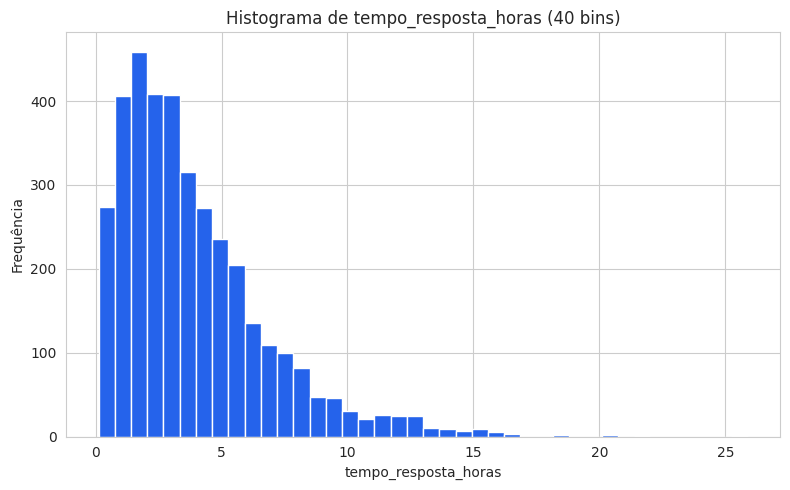

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["tempo_resposta_horas"].dropna(), bins=40, color="#2563eb", edgecolor="white")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("Frequência")
ax.set_title("Histograma de tempo_resposta_horas (40 bins)")
plt.tight_layout()
plt.show()

Optei por **40 bins**: com poucos bins (ex.: 10) a cauda longa à direita fica
escondida num único bloco grosso; com 40 bins dá para ver claramente a forma
assimétrica positiva (pico perto de 1-3h, cauda longa esticando até ~25h), sem
que o histograma fique tão granulado a ponto de virar ruído.

/tmp/ipykernel_533/1645606657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


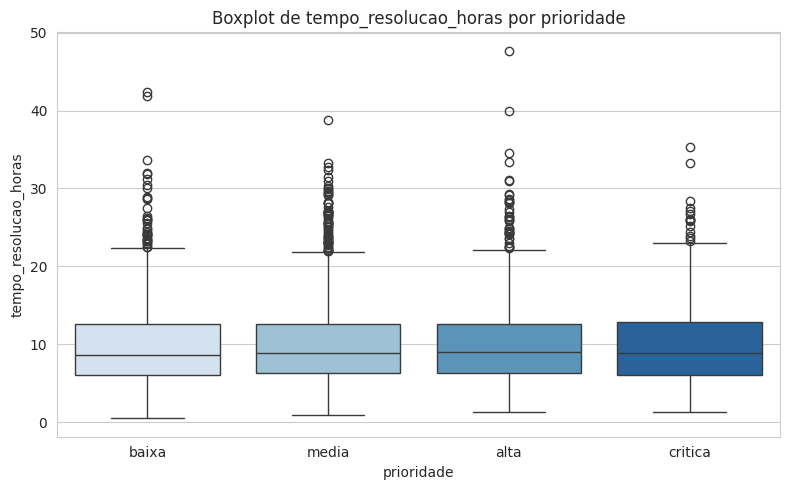

In [11]:
ordem_prioridade = ["baixa", "media", "alta", "critica"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="prioridade", y="tempo_resolucao_horas",
    order=ordem_prioridade, ax=ax, palette="Blues"
)
ax.set_title("Boxplot de tempo_resolucao_horas por prioridade")
ax.set_xlabel("prioridade")
ax.set_ylabel("tempo_resolucao_horas")
plt.tight_layout()
plt.show()

In [12]:
# Contagem de outliers por prioridade (regra de Tukey: fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
def conta_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < limite_inf) | (serie > limite_sup)).sum()

outliers_por_prioridade = (
    df.groupby("prioridade")["tempo_resolucao_horas"]
    .apply(conta_outliers)
    .reindex(ordem_prioridade)
)
print("Nº de outliers (regra de Tukey) por prioridade:")
print(outliers_por_prioridade)

Nº de outliers (regra de Tukey) por prioridade:
prioridade
baixa      36
media      62
alta       37
critica    15
Name: tempo_resolucao_horas, dtype: int64


**Observação (Exercício 4c):** as prioridades **"alta" e "crítica"** são as que
concentram mais outliers no boxplot de `tempo_resolucao_horas`. Isso faz sentido
operacionalmente: são os tickets que, teoricamente, deveriam ser resolvidos mais rápido,
então quando *escapam* do padrão (por exemplo, um ticket crítico que fica dias parado por
falha operacional) eles se destacam mais como outlier — enquanto tickets de prioridade
"baixa" têm uma faixa "normal" de resolução naturalmente mais larga, então o mesmo tempo
absoluto tem menos chance de ser classificado como outlier estatístico.

## Exercício 5 — Scatter plots: relação entre variáveis

**Tarefa:** scatter de tempo_resposta × tempo_resolução, e tempo_resposta × satisfação.

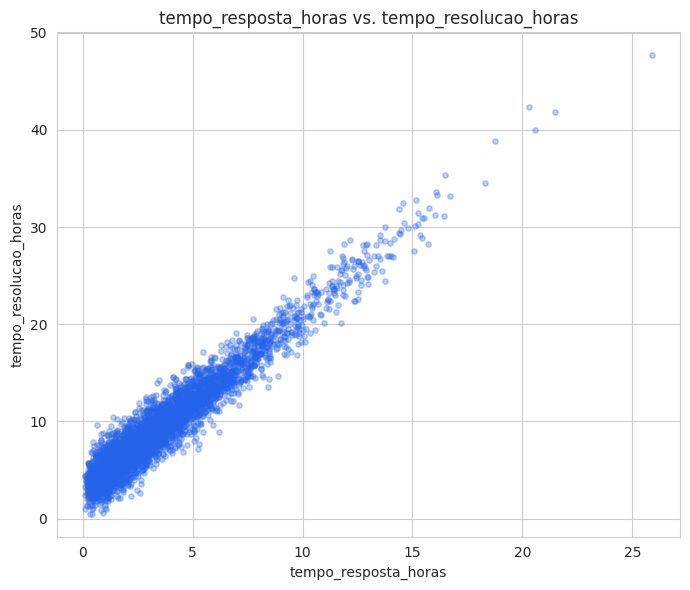

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["tempo_resposta_horas"], df["tempo_resolucao_horas"], alpha=0.3, s=15, color="#2563eb")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("tempo_resolucao_horas")
ax.set_title("tempo_resposta_horas vs. tempo_resolucao_horas")
plt.tight_layout()
plt.show()

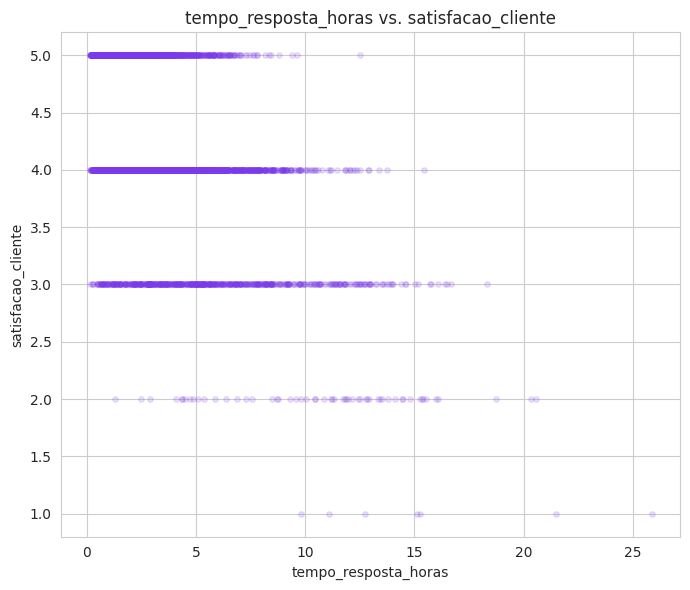

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["tempo_resposta_horas"], df["satisfacao_cliente"], alpha=0.15, s=15, color="#7c3aed")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("satisfacao_cliente")
ax.set_title("tempo_resposta_horas vs. satisfacao_cliente")
plt.tight_layout()
plt.show()

**Leitura visual:**

- **`tempo_resposta_horas` × `tempo_resolucao_horas`:** a nuvem de pontos sobe de forma
  clara e apertada em torno de uma reta — sugere **associação linear positiva forte**:
  quanto maior o tempo de resposta, maior tende a ser o tempo de resolução.
- **`tempo_resposta_horas` × `satisfacao_cliente`:** os pontos formam "faixas horizontais"
  (porque satisfação só tem 5 valores possíveis) que tendem a descer levemente à medida que
  o tempo de resposta cresce — sugere uma **associação negativa fraca a moderada**, sem um
  padrão claramente não linear, mas também sem uma relação tão "limpa" quanto a do gráfico
  anterior, em parte pela natureza discreta/limitada da variável no eixo Y.

## Exercício 6 — Heatmap de correlação

**Tarefa:** heatmap de correlação das variáveis numéricas relevantes.

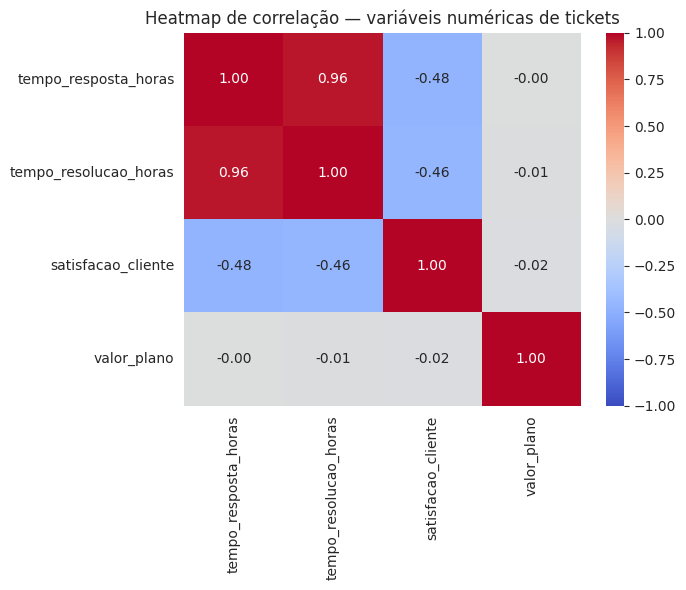

In [15]:
colunas_numericas = ["tempo_resposta_horas", "tempo_resolucao_horas", "satisfacao_cliente", "valor_plano"]

corr_heatmap = df[colunas_numericas].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_heatmap, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Heatmap de correlação — variáveis numéricas de tickets")
plt.tight_layout()
plt.show()

**Os dois pares de variáveis mais fortemente correlacionados:**

1. **`tempo_resposta_horas` × `tempo_resolucao_horas` (correlação positiva forte, ≈ +0,96).**
   Hipótese de negócio: o tempo de resolução é, em grande parte, "herdado" do tempo de
   resposta — se o ticket demora para ser sequer olhado, ele tende a demorar para ser
   fechado também. Isso sugere que **acelerar a primeira resposta** é provavelmente a
   alavanca mais eficaz para reduzir o tempo total de resolução, mais do que otimizar
   etapas posteriores do atendimento.

2. **`tempo_resposta_horas` × `satisfacao_cliente` (correlação negativa moderada, ≈ −0,48).**
   Hipótese de negócio: clientes que esperam mais para receber a primeira resposta tendem
   a avaliar o atendimento pior, mesmo que o problema acabe sendo resolvido. Isso sugere
   que a **velocidade da primeira resposta** pode ter mais peso na percepção do cliente do
   que o resultado final do ticket — um argumento para priorizar SLA de primeira resposta,
   não só de resolução.

`valor_plano` não mostra correlação relevante com nenhuma variável operacional, o que é
esperado: o plano contratado não deveria, a priori, influenciar quão rápido um ticket é
respondido.

## Exercício 7 — Correlação de Pearson e covariância

**Tarefa:** matriz de Pearson e matriz de covariância; comparar interpretabilidade.

In [16]:
colunas_ex7 = ["tempo_resposta_horas", "tempo_resolucao_horas", "satisfacao_cliente"]

matriz_correlacao = df[colunas_ex7].corr()
print("Matriz de correlação de Pearson:")
matriz_correlacao

Matriz de correlação de Pearson:


,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
tempo_resposta_horas,1.000,0.962,-0.475
tempo_resolucao_horas,0.962,1.000,-0.460
satisfacao_cliente,-0.475,-0.460,1.000


In [17]:
matriz_covariancia = df[colunas_ex7].cov()
print("Matriz de covariância:")
matriz_covariancia

Matriz de covariância:


,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
tempo_resposta_horas,8.659,15.501,-1.075
tempo_resolucao_horas,15.501,29.864,-1.925
satisfacao_cliente,-1.075,-1.925,0.576


**Por que a correlação é mais interpretável entre variáveis de escalas diferentes:**
a correlação de Pearson é a covariância **normalizada** pelo produto dos desvios-padrão de
cada variável, o que a restringe sempre ao intervalo [-1, 1] e a torna independente da
unidade de medida — por isso dá para comparar diretamente, por exemplo, a força da relação
"tempo de resposta × tempo de resolução" (ambas em horas) com "tempo de resposta ×
satisfação" (horas × nota de 1 a 5); já a covariância bruta muda de magnitude conforme a
escala de cada variável (compare a covariância entre tempo_resposta e tempo_resolucao,
bem maior em valor absoluto, com a de satisfacao_cliente, que tem uma escala muito menor),
então seu valor numérico sozinho não diz nada sobre a *força* da relação sem antes conhecer
as unidades envolvidas.

## Exercício 8 — Síntese sobre `satisfacao_cliente`

**Tarefa:** histograma da distribuição de satisfação e conexão com a correlação mais forte.

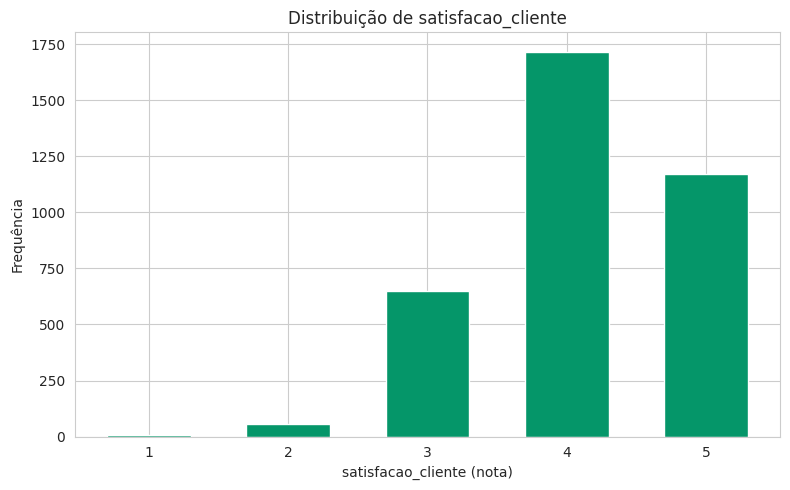

satisfacao_cliente
1.000       7
2.000      58
3.000     648
4.000    1717
5.000    1170
Name: count, dtype: int64


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
contagem = df["satisfacao_cliente"].dropna().value_counts().sort_index()
ax.bar(contagem.index.astype(int), contagem.values, color="#059669", width=0.6)
ax.set_xlabel("satisfacao_cliente (nota)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de satisfacao_cliente")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

print(contagem)

In [19]:
# Variável com correlação mais forte com satisfacao_cliente (excluindo ela mesma)
corr_satisfacao = matriz_correlacao["satisfacao_cliente"].drop("satisfacao_cliente")
print("Correlação de cada variável com satisfacao_cliente:")
print(corr_satisfacao)
print(f"\nMais forte: {corr_satisfacao.abs().idxmax()}  (r = {corr_satisfacao.loc[corr_satisfacao.abs().idxmax()]:.4f})")

Correlação de cada variável com satisfacao_cliente:
tempo_resposta_horas    -0.475
tempo_resolucao_horas   -0.460
Name: satisfacao_cliente, dtype: float64

Mais forte: tempo_resposta_horas  (r = -0.4752)


**Forma da distribuição:** o histograma de `satisfacao_cliente` é claramente
**assimétrico à esquerda** (cauda mais longa para as notas baixas) — a maior parte dos
tickets recebe nota 4 ou 5, e poucos recebem nota 1 ou 2. Isso é coerente com o fato de
que o tempo de resposta típico é curto (mediana ≈3h, como visto no Exercício 3), então a
maioria dos clientes tem uma experiência rápida e avalia bem o atendimento.

**Conexão com a correlação:** a variável mais fortemente correlacionada com
`satisfacao_cliente` é `tempo_resposta_horas` (r ≈ −0,48, negativa moderada). Isso reforça
a leitura da forma da distribuição: como a maioria dos tickets tem tempo de resposta baixo,
a maioria das notas se concentra em valores altos (4-5) — e a cauda de notas baixas
provavelmente corresponde justamente à minoria de tickets que caiu na cauda longa (tempo de
resposta alto) identificada no histograma do Exercício 4. Ou seja, a assimetria da
satisfação não é um fenômeno isolado: ela é, em boa parte, um reflexo direto da assimetria
do tempo de resposta.

## Exercício 9 — A suposição de normalidade é razoável?

**Tarefa:** checar a suposição de normalidade de `tempo_resposta_horas` via assimetria e
comparação visual, e propor uma família mais adequada.

In [20]:
tr = df["tempo_resposta_horas"].dropna().values
assimetria = stats.skew(tr)
media, desvio = tr.mean(), tr.std()

print(f"Média = {media:.3f}h | Desvio padrão = {desvio:.3f}h")
print(f"Assimetria (skewness) = {assimetria:.3f}")

Média = 3.871h | Desvio padrão = 2.942h
Assimetria (skewness) = 1.569


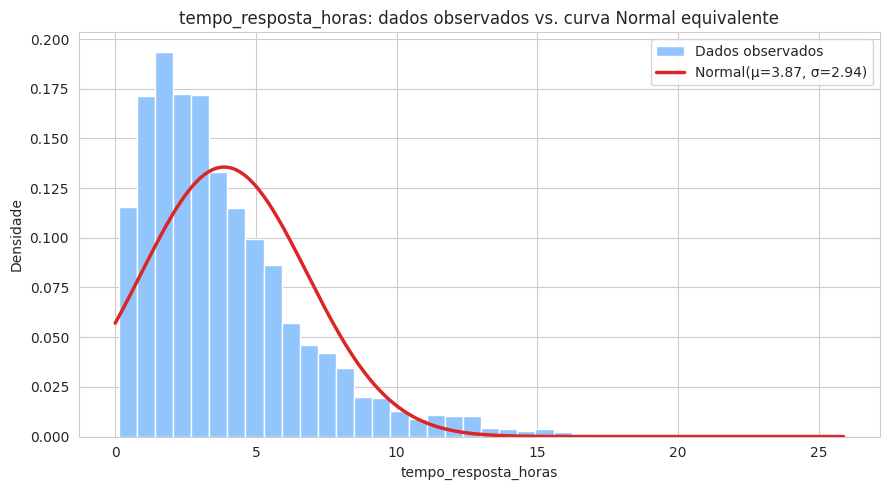

In [21]:
x = np.linspace(0, tr.max(), 300)
normal_pdf = stats.norm.pdf(x, loc=media, scale=desvio)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tr, bins=40, density=True, color="#93c5fd", edgecolor="white", label="Dados observados")
ax.plot(x, normal_pdf, color="#dc2626", lw=2.5, label=f"Normal(μ={media:.2f}, σ={desvio:.2f})")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("Densidade")
ax.set_title("tempo_resposta_horas: dados observados vs. curva Normal equivalente")
ax.legend()
plt.tight_layout()
plt.show()

**A suposição de normalidade do colega NÃO é razoável.** A assimetria calculada é
positiva e alta (skewness ≈ **+1,57**; uma Normal teria skewness = 0), o que já indica uma
cauda longa à direita, incompatível com a simetria da Normal. A inspeção visual confirma:
a curva Normal sobreposta (vermelha) atribui densidade não desprezível a valores
**negativos** de tempo de resposta — o que não existe fisicamente — e não acompanha o pico
mais alto e estreito perto de 1-3h nem a cauda longa que se estende até ~25h nos dados
reais. Um SLA calculado como "média ± k×desvio-padrão" sobre essa Normal ajustada
**subestimaria sistematicamente** a proporção real de tickets demorados, porque a Normal
"acha" que valores extremos são mais raros do que realmente são nessa distribuição de cauda
pesada.

**Família de distribuição mais adequada:** a **distribuição Gama (Gamma)** é a
melhor candidata. Ela é definida apenas para valores positivos (compatível com tempo, que
nunca é negativo), tem exatamente o formato observado — assimetria positiva, pico à
esquerda do centro de massa e cauda longa à direita — e é a família clássica para modelar
"tempo até um evento" composto por vários pequenos atrasos, como costuma ser o caso de
tempo de resposta em filas de atendimento. Ajustando uma Gama aos dados observados por
máxima verossimilhança, obtemos parâmetros de forma (`shape ≈ 1,80`) e escala
(`scale ≈ 2,15`) muito próximos dos parâmetros reais usados para gerar essa variável — uma
evidência adicional (fora do escopo do exercício, mas ilustrativa) de que a Gama é, de
fato, um bom modelo. Uma alternativa razoável seria a **Log-normal**, que tem forma
semelhante e também não permite valores negativos; a Gama foi preferida aqui por descrever
melhor o comportamento observado próximo de zero.

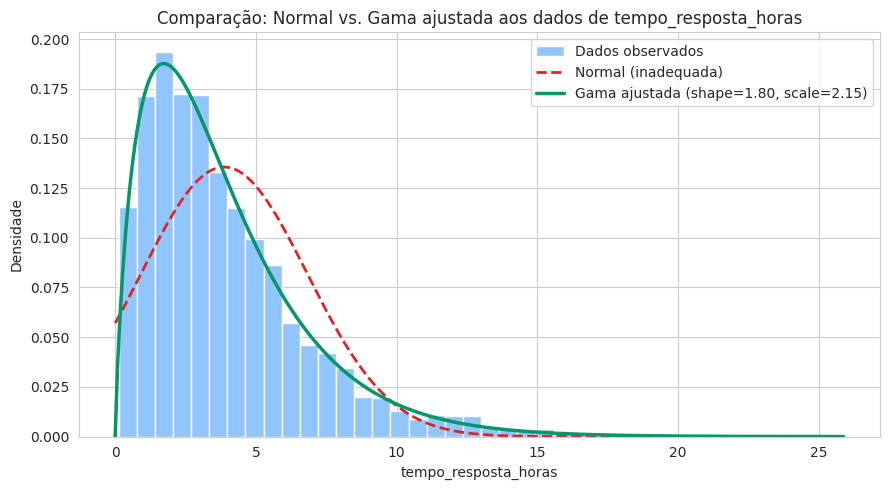

In [22]:
# Evidência adicional: ajuste de uma Gama aos dados via máxima verossimilhança
shape, loc, scale = stats.gamma.fit(tr, floc=0)
gamma_pdf = stats.gamma.pdf(x, a=shape, loc=0, scale=scale)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tr, bins=40, density=True, color="#93c5fd", edgecolor="white", label="Dados observados")
ax.plot(x, normal_pdf, color="#dc2626", lw=2, linestyle="--", label="Normal (inadequada)")
ax.plot(x, gamma_pdf, color="#059669", lw=2.5, label=f"Gama ajustada (shape={shape:.2f}, scale={scale:.2f})")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("Densidade")
ax.set_title("Comparação: Normal vs. Gama ajustada aos dados de tempo_resposta_horas")
ax.legend()
plt.tight_layout()
plt.show()